# 🚕 Dynamic Pricing Optimization — EDA & Model Training

This notebook documents the full training workflow. The production-grade implementation lives in `src/train_model.py`.


## 1. Setup

Install requirements with `pip install -r requirements.txt` before running the notebook.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

from src.train_model import (
    load_dataset, validate_columns, FEATURES, TARGET, CATEGORICAL, NUMERIC,
    build_preprocessor, make_models,
    RANDOM_STATE, MODEL_DIR
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
print("Project root:", ROOT)


C:\D Drive KK\CDC\ML Project\dynamic-pricing-india-ready\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\D Drive KK\CDC\ML Project\dynamic-pricing-india-ready


## 2. Load and validate the dataset

The public Kaggle dataset is downloaded with `kagglehub`. Only completed trips with observed fares are used for the fare model.

In [2]:
df = load_dataset()
validate_columns(df)

print("Raw shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())


Raw shape: (500000, 29)
Columns: ['Trip_ID', 'Customer_ID', 'Driver_ID', 'Customer_Age', 'Customer_Gender', 'Is_Prime_Member', 'Num_Previous_Trips', 'Driver_Age', 'Driver_Gender', 'Driver_Experience_Years', 'Driver_Rating', 'Pickup_City', 'Drop_City', 'Vehicle_Type', 'Distance_KM', 'Duration_Min', 'Day_of_Week', 'Time_of_Day', 'Weather_Condition', 'Traffic_Level', 'Surge_Multiplier', 'Wait_Time_Min', 'Discount_Percent', 'Payment_Mode', 'Trip_Rating', 'Is_Cancelled', 'Cancellation_Reason', 'Trip_Status', 'Total_Fare']


,Trip_ID,Customer_ID,Driver_ID,Customer_Age,Customer_Gender,Is_Prime_Member,Num_Previous_Trips,Driver_Age,Driver_Gender,Driver_Experience_Years,Driver_Rating,Pickup_City,Drop_City,Vehicle_Type,Distance_KM,Duration_Min,Day_of_Week,Time_of_Day,Weather_Condition,Traffic_Level,Surge_Multiplier,Wait_Time_Min,Discount_Percent,Payment_Mode,Trip_Rating,Is_Cancelled,Cancellation_Reason,Trip_Status,Total_Fare
0,TRIP59306159,508925,711617,56,M,0,14,55,M,33,3.90,Ahmedabad,Ahmedabad,Sedan,18.19,39.8,Thursday,Night,Cloudy,High,1.16,9.1,8.9,UPI,5.00,0,NaN,Completed,309.02
1,TRIP36889796,577394,701476,34,M,0,13,32,M,7,4.24,Ahmedabad,Ahmedabad,Bike,6.29,13.4,Tuesday,Afternoon,Foggy,High,1.37,0.5,17.4,Debit Card,4.01,0,NaN,Completed,53.51
2,TRIP27798006,565456,716253,52,F,0,11,52,M,29,4.04,Pune,Pune,Bike,8.54,38.9,Thursday,Morning,Rainy,High,1.63,7.2,11.2,UPI,4.18,0,NaN,Completed,92.40
3,TRIP03905091,543887,719428,20,F,1,29,23,M,0,4.32,Hyderabad,Hyderabad,Bike,3.88,7.6,Tuesday,Afternoon,Clear,Low,1.00,3.6,5.7,Debit Card,3.88,0,NaN,Completed,36.02
4,TRIP40685779,543301,707404,48,F,0,8,25,F,3,4.38,Pune,Pune,Mini,27.58,66.9,Wednesday,Afternoon,Clear,Severe,1.53,4.4,2.0,UPI,4.63,0,NaN,Completed,475.72


In [3]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
})
display(summary)
print("Cancellation rate:", round(df["Is_Cancelled"].mean() * 100, 2), "%")


,dtype,missing,missing_pct
Trip_ID,str,0,0.00
Customer_ID,int64,0,0.00
Driver_ID,int64,0,0.00
Customer_Age,int64,0,0.00
Customer_Gender,str,0,0.00
Is_Prime_Member,int64,0,0.00
Num_Previous_Trips,int64,0,0.00
Driver_Age,int64,0,0.00
Driver_Gender,str,0,0.00
Driver_Experience_Years,int64,0,0.00


Cancellation rate: 6.27 %


In [4]:
completed = df[df["Is_Cancelled"] == 0].dropna(subset=[TARGET]).copy()
print(f"Completed trips used for modeling: {len(completed):,}")
display(completed[FEATURES + [TARGET]].describe(include="all").T.head(20))


Completed trips used for modeling: 468,671


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Pickup_City,468671,8,Mumbai,59030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Type,468671,6,Mini,126683,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance_KM,468671.0,NaN,NaN,NaN,30.193982,93.549413,0.5,3.54,6.31,10.63,599.96
Duration_Min,468671.0,NaN,NaN,NaN,40.453287,87.124948,0.9,9.1,16.6,29.7,715.8
Time_of_Day,468671,5,Evening,130980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather_Condition,468671,5,Clear,257833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Traffic_Level,468671,4,Medium,164974,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_Week,468671,7,Sunday,67381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is_Prime_Member,468671.0,NaN,NaN,NaN,0.380664,0.485551,0.0,0.0,0.0,1.0,1.0
Driver_Rating,468671.0,NaN,NaN,NaN,4.294012,0.385495,2.28,4.03,4.3,4.57,5.0


## 3. Exploratory Data Analysis

C:\Users\HP\AppData\Local\Temp\ipykernel_16628\3828598844.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(completed["Total_Fare"], vert=False)


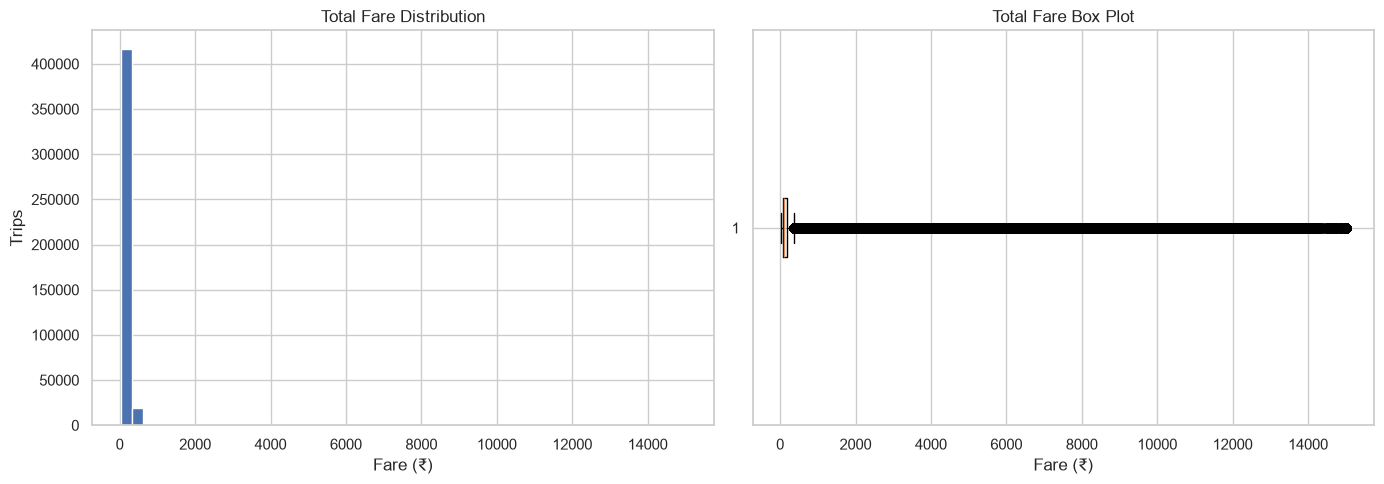

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(completed["Total_Fare"], bins=50)
axes[0].set_title("Total Fare Distribution")
axes[0].set_xlabel("Fare (₹)")
axes[0].set_ylabel("Trips")

axes[1].boxplot(completed["Total_Fare"], vert=False)
axes[1].set_title("Total Fare Box Plot")
axes[1].set_xlabel("Fare (₹)")
plt.tight_layout()
plt.show()


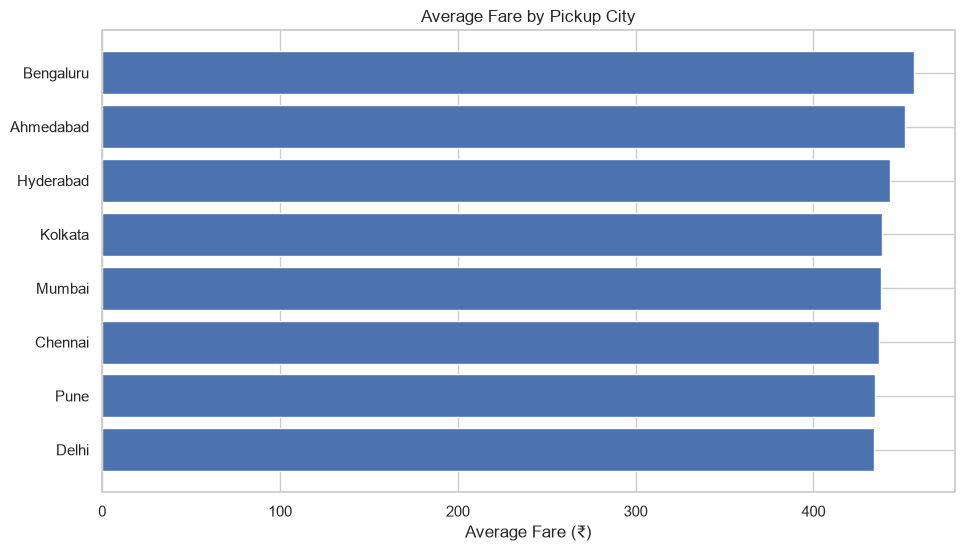

In [6]:
city_fare = (
    completed.groupby("Pickup_City")["Total_Fare"]
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(11, 6))
plt.barh(city_fare.index[::-1], city_fare.values[::-1])
plt.xlabel("Average Fare (₹)")
plt.title("Average Fare by Pickup City")
plt.show()


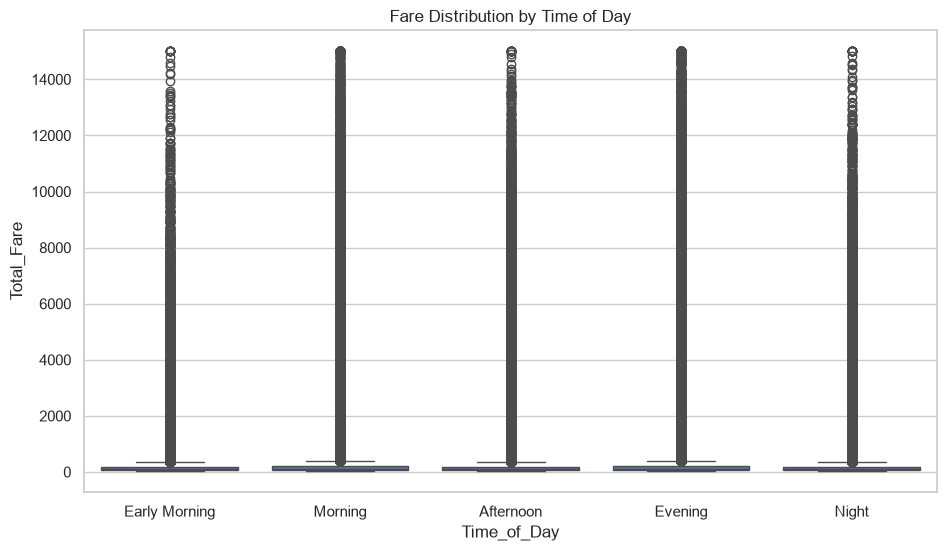

In [7]:
time_order = ["Early Morning", "Morning", "Afternoon", "Evening", "Night"]
available = [x for x in time_order if x in completed["Time_of_Day"].unique()]
plt.figure(figsize=(11, 6))
sns.boxplot(data=completed, x="Time_of_Day", y="Total_Fare", order=available)
plt.title("Fare Distribution by Time of Day")
plt.show()


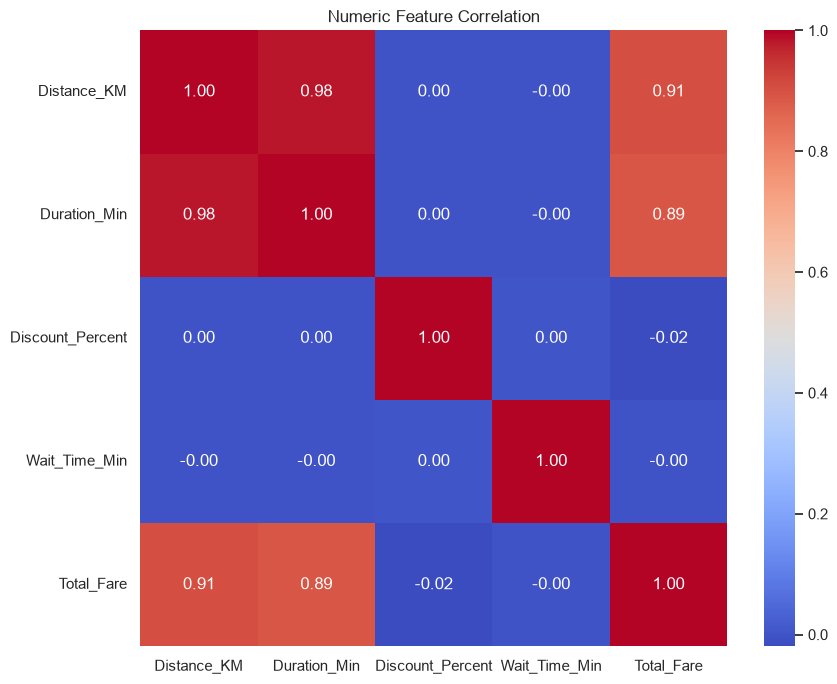

In [8]:
numeric_cols = [
    "Distance_KM", "Duration_Min",
    "Discount_Percent", "Wait_Time_Min", "Total_Fare"
]
plt.figure(figsize=(9, 7))
sns.heatmap(completed[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Numeric Feature Correlation")
plt.tight_layout()
plt.show()


## 4. Fare-model features and split

Preprocessing is kept inside a pipeline so the deployed application uses exactly the same transformations as training.

In [9]:
X = completed[FEATURES].copy()
y = completed[TARGET].astype(float)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (374936, 10) Test: (93735, 10)


## 5. Compare models

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
fitted = {}

for name, pipe in make_models(build_preprocessor()).items():
    print("Training:", name)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    })
    fitted[name] = pipe

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df.style.format({"RMSE":"{:.2f}", "MAE":"{:.2f}", "R2":"{:.4f}"}))
print("Best model:", results_df.iloc[0]["Model"])


Training: Ridge Regression


Training: Random Forest


Training: Gradient Boosting


,Model,RMSE,MAE,R2
0,Random Forest,143.50,32.86,0.9890
1,Gradient Boosting,170.63,46.96,0.9845
2,Ridge Regression,550.48,202.11,0.8388


Best model: Random Forest


In [11]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted[best_name]
results_df.to_csv(MODEL_DIR / "model_comparison.csv", index=False)


## 7. Save artifacts

`src/train_model.py` is the canonical reproducible training entry point. Run it from the project root to write the model, metadata, and metrics.

In [12]:
# For this notebook, persist the already-fitted best model.
from joblib import dump
dump(best_model, MODEL_DIR / "fare_model.joblib", compress=3)
print("Saved:", MODEL_DIR / "fare_model.joblib")


Saved: C:\D Drive KK\CDC\ML Project\dynamic-pricing-india-ready\models\fare_model.joblib


## 8. Feature importance

In [13]:
pre = best_model.named_steps["preprocess"]
est = best_model.named_steps["model"]
names = pre.get_feature_names_out()

if hasattr(est, "feature_importances_"):
    vals = est.feature_importances_
else:
    vals = np.abs(est.coef_).ravel()

imp = pd.DataFrame({"Feature": names, "Importance": vals})
imp = imp.sort_values("Importance", ascending=False).head(15)
display(imp)


,Feature,Importance
0,Distance_KM,0.833898
13,Vehicle_Type_Bike,0.054811
14,Vehicle_Type_Mini,0.020971
12,Vehicle_Type_Auto,0.017892
17,Vehicle_Type_Sedan,0.015331
31,Traffic_Level_Severe,0.010608
15,Vehicle_Type_Prime,0.010000
16,Vehicle_Type_SUV,0.009824
28,Traffic_Level_High,0.004743
27,Weather_Condition_Stormy,0.003838


## 9. Key limitations

- The dataset is synthetic.
- A random holdout is useful for a baseline, but time-based validation is preferable when timestamps are available.
- Surge multiplier is retained only as a dataset column for EDA; it is not used as a model input or user input.
- The dashboard uses a transparent distance-to-duration proxy; production should use routing/ETA data.